In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

# Evaluating operators trained on synthetic data

In [2]:
# --!--------------------------------------------------------------------------
# --! load trained models

# --! ensure reproducible results
seed = 5
torch.manual_seed(seed)

model_g = torch.load('models/care_sim_g.pt', weights_only=False)
model_l = torch.load('models/care_sim_l.pt', weights_only=False)

### Analysis of global operator eigenvalues

The trained operator successfully identifies the two modes present in the data, hence two pairs of complex eigenvalues.

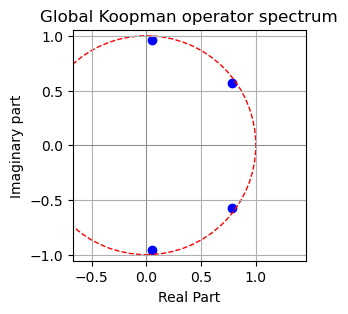

In [3]:
# --!--------------------------------------------------------------------------!
# --! visualize global operator eigenvalues

with torch.no_grad():
    eigvals, eigvecs = torch.linalg.eig(model_g.operator_sta.model.weight)
    utils.disp_spectrum(eigvals)

Furthermore, amplitude plots below confirm that each pair of complex eigenvalues contributes selectively depending on the frequency content of input time series.

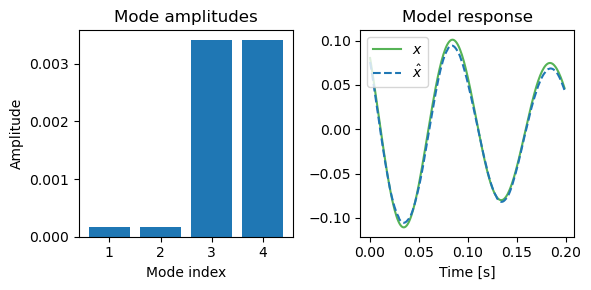

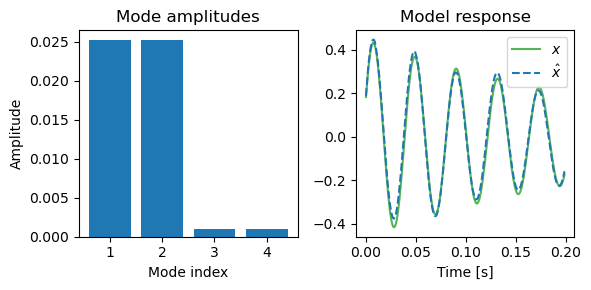

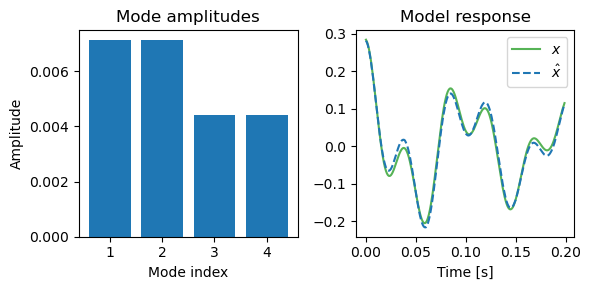

In [4]:
# --!--------------------------------------------------------------------------!
# --! analyze the amplitude of global operator eigenvalues

dataset_dir         = 'data/train_sim_g'
timeseries_nsample  = 200

with torch.no_grad():
    for timeseries_pos in range(3):
        utils.disp_spectrum_amps(model_g, dataset_dir, timeseries_nsample, timeseries_pos)

### Global model evaluation

We evaluate the trained global operator on test data featuring a transition. As shown below, the global operator fails to capture the transient dynamics: it predicts a persistent superposition of the two sinusoids, overestimating frequency components during the transition. This outcome aligns with known limitations of classical DMD methods, which assume stationary linear evolution and lack mechanisms for adapting to distribution shifts or abrupt changes in system behavior.

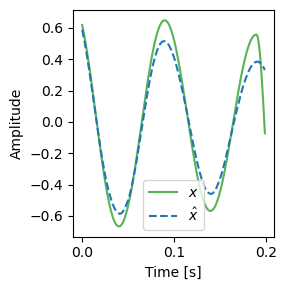

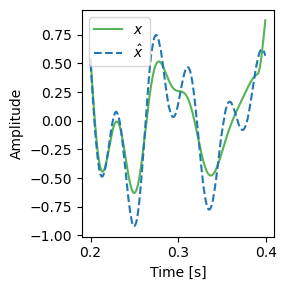

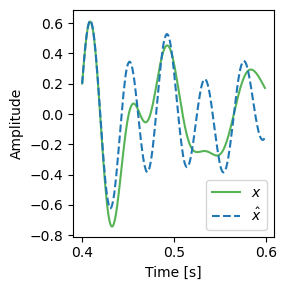

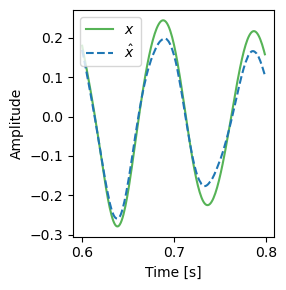

In [5]:
# --!--------------------------------------------------------------------------
# --! evaluate a global model

eval_dataset_dir        = 'data/eval_sim'
eval_timeseries_nsample = 200

with torch.no_grad():
    alphas = [1.0, 1.0, 1.0, 1.0]
    utils.eval_model(model_g, eval_dataset_dir, eval_timeseries_nsample, alphas)


### Local model evaluation

The global results above motivate the incorporation of a local operator to complement the global one, enabling the model to adaptively respond to transient or time-varying phenomena in a structured manner.

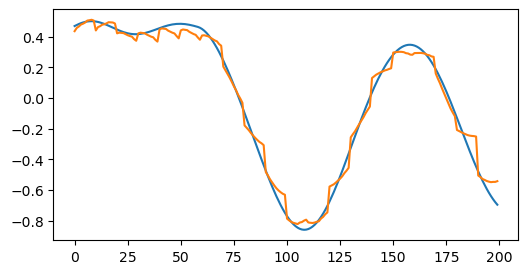

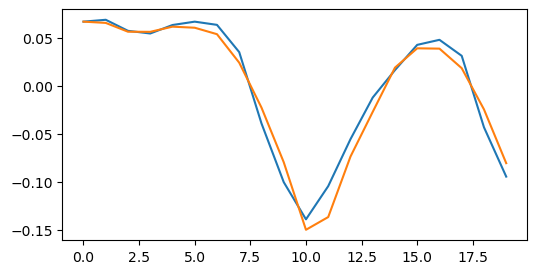

In [10]:
timeseries_nsample    = 200
subtimeseries_nsample = timeseries_nsample

with torch.no_grad():
    data_test   = utils.read_datafile('data/train_sim_l/test', timeseries_nsample)
    data        = data_test[1]
    timeseries  = torch.unsqueeze(data[:subtimeseries_nsample, :1], dim=0)
    outs        = model_l(timeseries, alpha=0.0)

    fun         = torch.squeeze(outs[2], 0)
    fun_predict = torch.squeeze(outs[3], 0)
    fun_idx = 3

    timeseries_predict = torch.squeeze(outs[4], 0)

    plt.figure(figsize=(6,3))
    plt.plot(data[:, 0])
    plt.plot(timeseries_predict[:, 0])
    plt.show()

    plt.figure(figsize=(6,3))
    plt.plot(fun[:, fun_idx])
    plt.plot(fun_predict[:, fun_idx])
    plt.show()

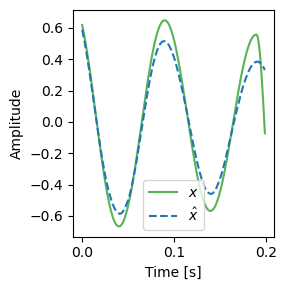

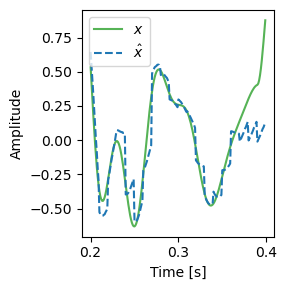

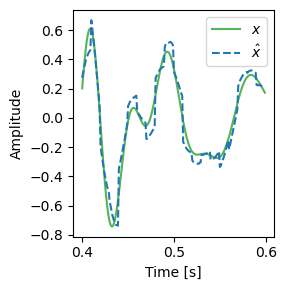

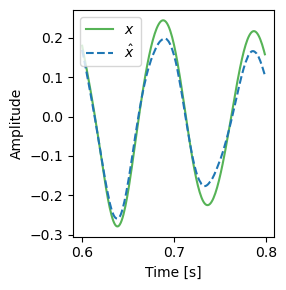

In [12]:
# --!--------------------------------------------------------------------------
# --! evaluate a local model

with torch.no_grad():
    # --! we reuse other parameters, but update alphas
    alpha = [1.0, 0.0, 0.1, 1.0]
    utils.eval_model(model_l, eval_dataset_dir, eval_timeseries_nsample, alpha)